In [403]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [404]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [405]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [406]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [407]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [408]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [409]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [410]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [411]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [412]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [413]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve, precision_recall_curve,
                           average_precision_score)

#Here we load/read the csv file.

In [414]:
df = pd.read_csv('Telecom(Telco) Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,N,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [415]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,N,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Here we drop customer id.

In [416]:
df = df.drop(columns=['customerID'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,N,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [417]:
print("Dataset shape:",df.shape)

Dataset shape: (7043, 20)


In [418]:
print("First fews rows of Dataset:")
df.head()

First fews rows of Dataset:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,N,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [419]:
print("Display the full information of Dataset:")
df.info()

Display the full information of Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMetho

#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [420]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [421]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [422]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [423]:
print("\nMissing values per column:")
df.isnull().sum().sum()


Missing values per column:


np.int64(0)

In [424]:
print("\nDisplay the Statistics:")
df.describe()


Display the Statistics:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [425]:
df.duplicated().sum()

np.int64(22)

In [426]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)
        

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [427]:
df.head(30)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,no,N,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,no,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,no,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,no,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#Exploratory Data Analysis 

#Basic understanding that how much customer churn out or not.

<function matplotlib.pyplot.show(close=None, block=None)>

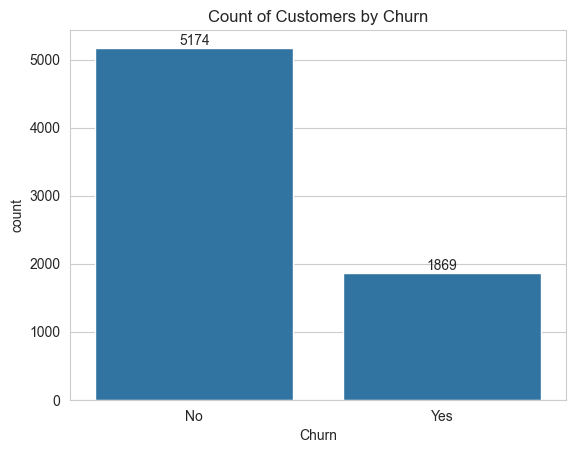

In [428]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show

In [429]:
#Use Groupby

In [430]:
gb = df.groupby("Churn").agg({'Churn':"count"})
gb

,Churn
Churn,
No,5174
Yes,1869


In [431]:
#If you want to see percentage.

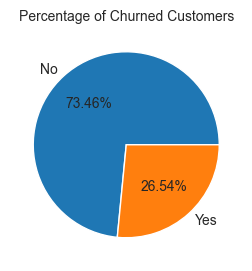

In [432]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers", fontsize = 10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out.
#now let's explore the reason behind it

#let's Explore Gender Basic.

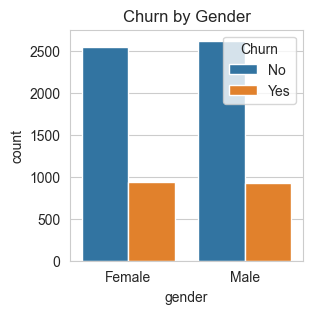

In [433]:
plt.figure(figsize = (3,3))
sns.countplot(x = "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.show()

#let's Explore SeniorCitizen Basic.

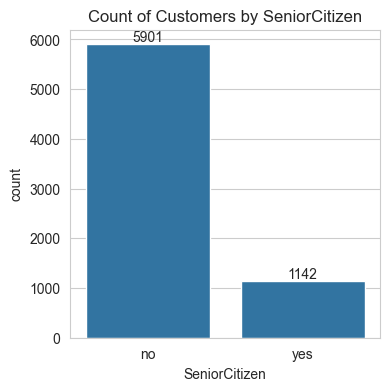

In [434]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df,)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by SeniorCitizen")
plt.show()

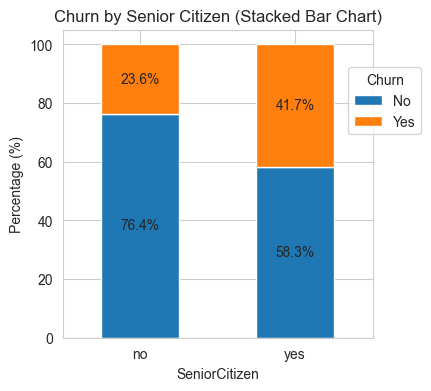

In [435]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 4))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))  # Customize legend location

plt.show()

#comparative a greater percentage of people in senior citizen category have churned.

#let's Explore Tenure Basic.

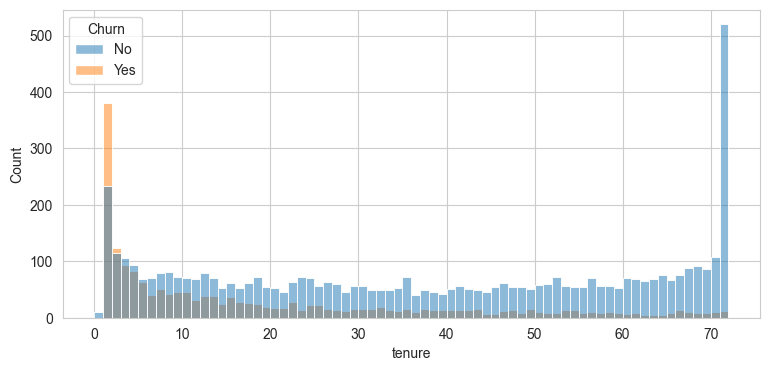

In [436]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services #1 or 2 months have churned

#Let's Explore Contract Basic.

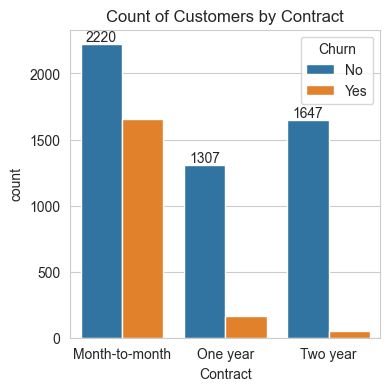

In [437]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

#people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract.

In [438]:
df.columns.values

<ArrowStringArray>
[          'gender',    'SeniorCitizen',          'Partner',
       'Dependents',           'tenure',     'PhoneService',
    'MultipleLines',  'InternetService',   'OnlineSecurity',
     'OnlineBackup', 'DeviceProtection',      'TechSupport',
      'StreamingTV',  'StreamingMovies',         'Contract',
 'PaperlessBilling',    'PaymentMethod',   'MonthlyCharges',
     'TotalCharges',            'Churn']
Length: 20, dtype: str

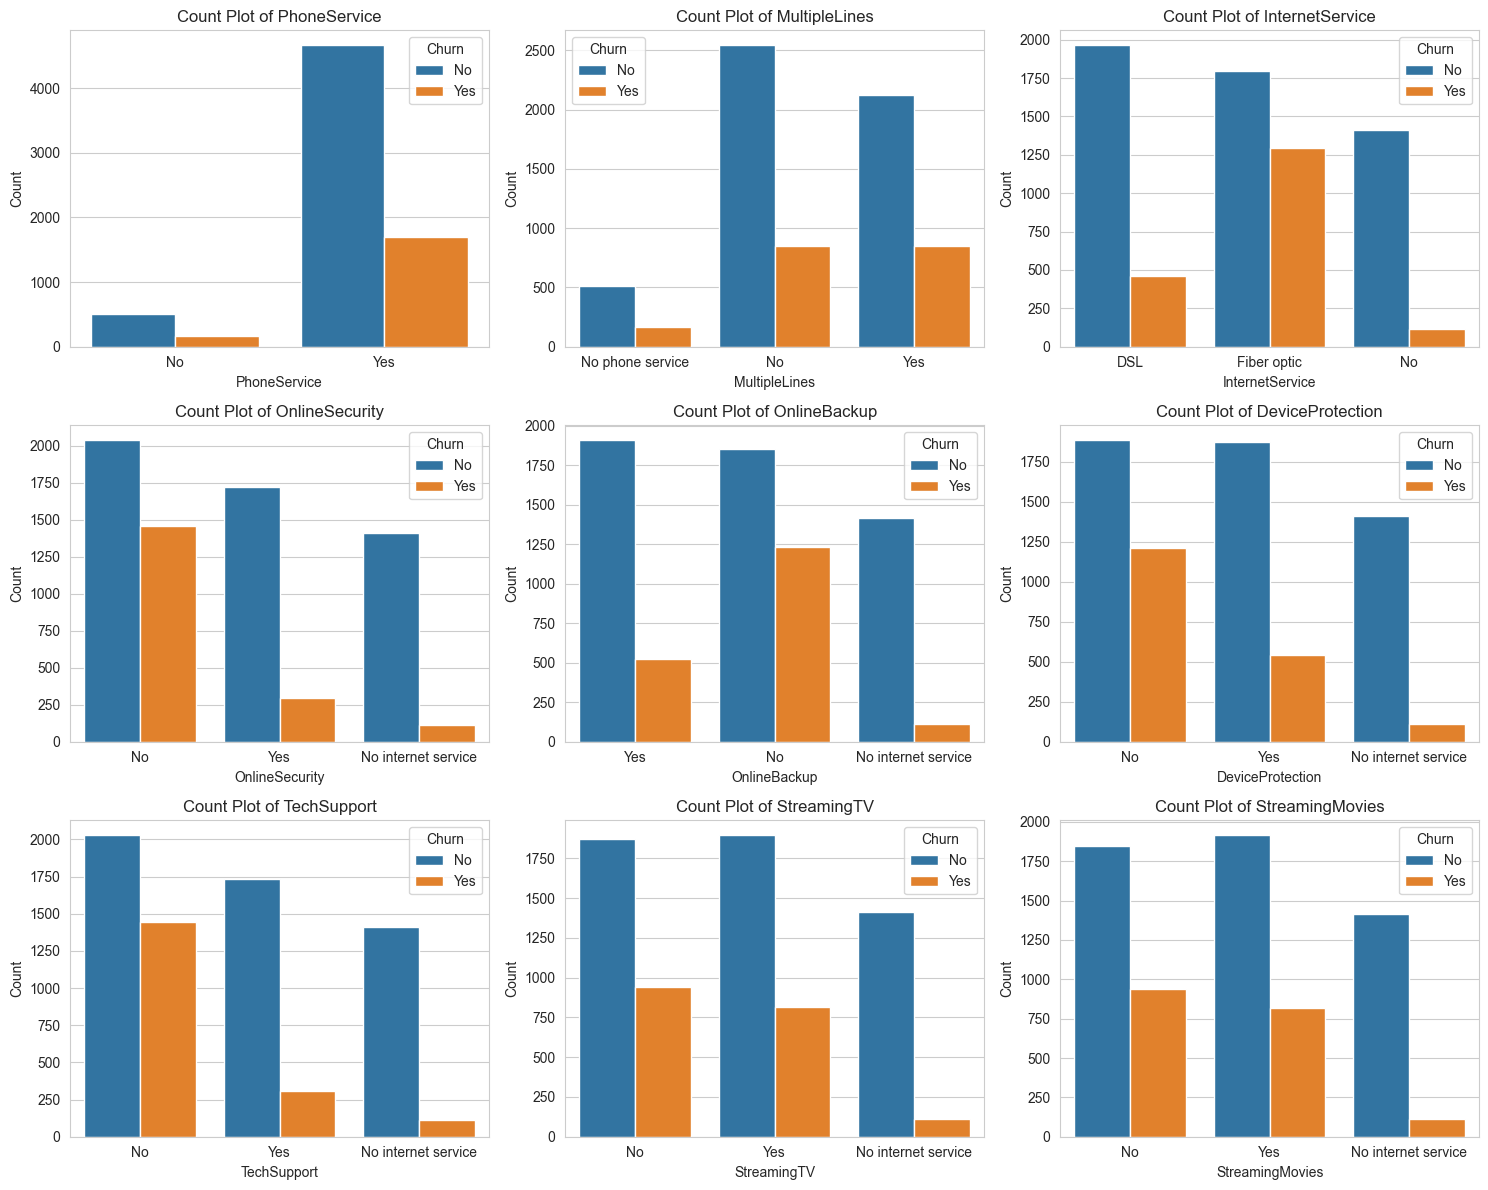

In [439]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns for the subplot grid (you can change this)
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))  # Adjust figsize as needed

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

#Let's Explore Payment Method.

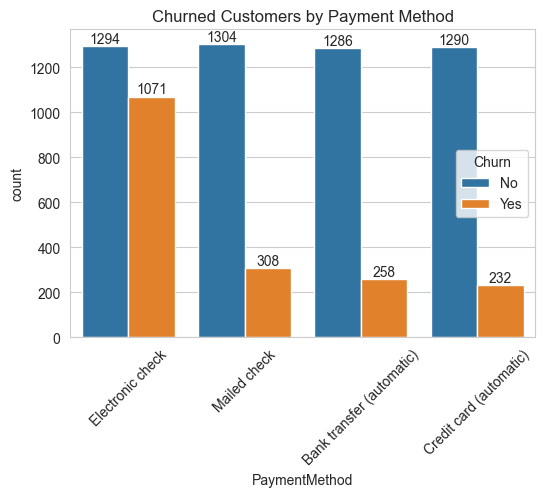

In [440]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation = 45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method.

In [441]:
# 1. Convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values in TotalCharges
missing_total_charges = df['TotalCharges'].isnull().sum()
print(f"Number of missing values in 'TotalCharges' after conversion: {missing_total_charges}")

# 2. Convert Churn to a binary numeric column (1 for 'Yes', 0 for 'No')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Convert SeniorCitizen to categorical ('Yes'/'No')
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Final check of data types for the modified columns
print("\nUpdated Data Types:")
print(df[['SeniorCitizen', 'TotalCharges', 'Churn']].info())

Number of missing values in 'TotalCharges' after conversion: 0

Updated Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SeniorCitizen  0 non-null      str    
 1   TotalCharges   7043 non-null   float64
 2   Churn          7043 non-null   int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 166.1 KB
None


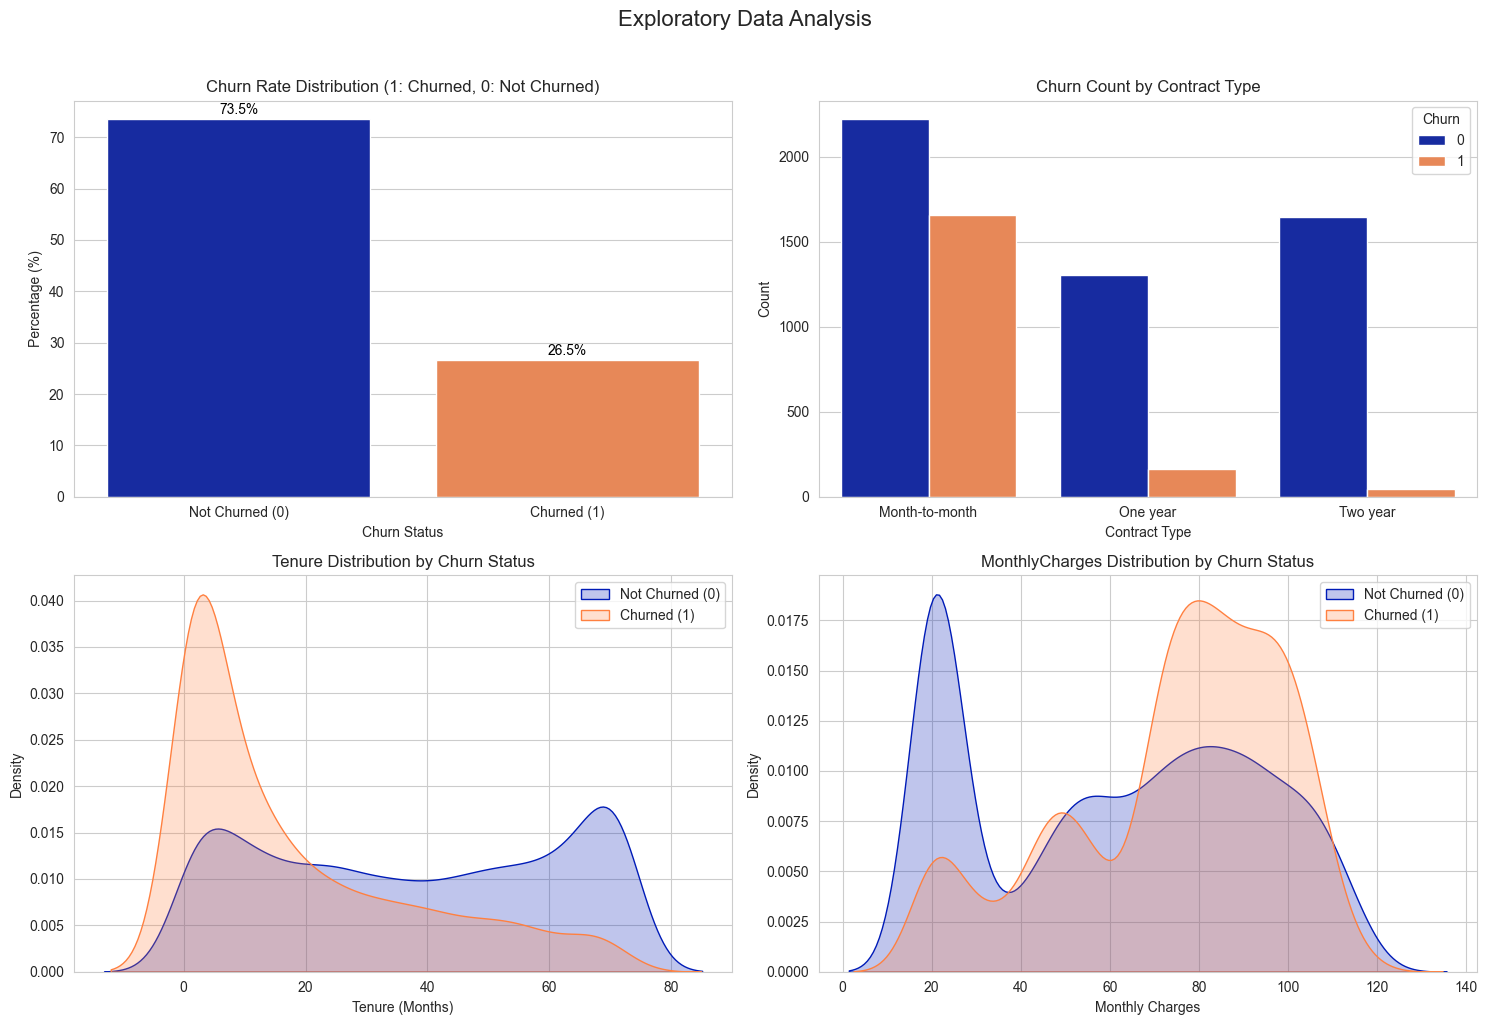

In [442]:
# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.suptitle('Exploratory Data Analysis', fontsize=16, y=1.02)

# --- Subplot 1: Churn Distribution ---
churn_counts = df['Churn'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
sns.barplot(x='Churn', y='percent', data=churn_counts, ax=axes[0, 0], palette=['#001BB7', '#FF8040'], hue='Churn', dodge=False, legend=False)
axes[0, 0].set_title('Churn Rate Distribution (1: Churned, 0: Not Churned)')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].set_xlabel('Churn Status')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Not Churned (0)', 'Churned (1)'])
for index, row in churn_counts.iterrows():
    axes[0, 0].text(index, row.percent + 1, f'{row.percent:.1f}%', color='black', ha="center")


# --- Subplot 2: Churn vs. Contract ---
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0, 1], palette=['#001BB7', '#FF8040'])
axes[0, 1].set_title('Churn Count by Contract Type')
axes[0, 1].set_xlabel('Contract Type')
axes[0, 1].set_ylabel('Count')

# --- Subplot 3 & 4: Numerical Feature Distributions (tenure and MonthlyCharges) ---
# Kernel Density Estimate plot for tenure
sns.kdeplot(df[df['Churn'] == 0]['tenure'], ax=axes[1, 0], label='Not Churned (0)', fill=True, color='#001BB7')
sns.kdeplot(df[df['Churn'] == 1]['tenure'], ax=axes[1, 0], label='Churned (1)', fill=True, color='#FF8040')
axes[1, 0].set_title('Tenure Distribution by Churn Status')
axes[1, 0].set_xlabel('Tenure (Months)')
axes[1, 0].legend()

# Kernel Density Estimate plot for MonthlyCharges
sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], ax=axes[1, 1], label='Not Churned (0)', fill=True, color='#001BB7')
sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], ax=axes[1, 1], label='Churned (1)', fill=True, color='#FF8040')
axes[1, 1].set_title('MonthlyCharges Distribution by Churn Status')
axes[1, 1].set_xlabel('Monthly Charges')
axes[1, 1].legend()

plt.tight_layout()

In [443]:
# Encode Gender column{'Female': 0, 'Male': 1}
le_gender = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])

# Print readable mappings
gender_mapping = dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))

print("Gender Mapping:", gender_mapping)

Gender Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


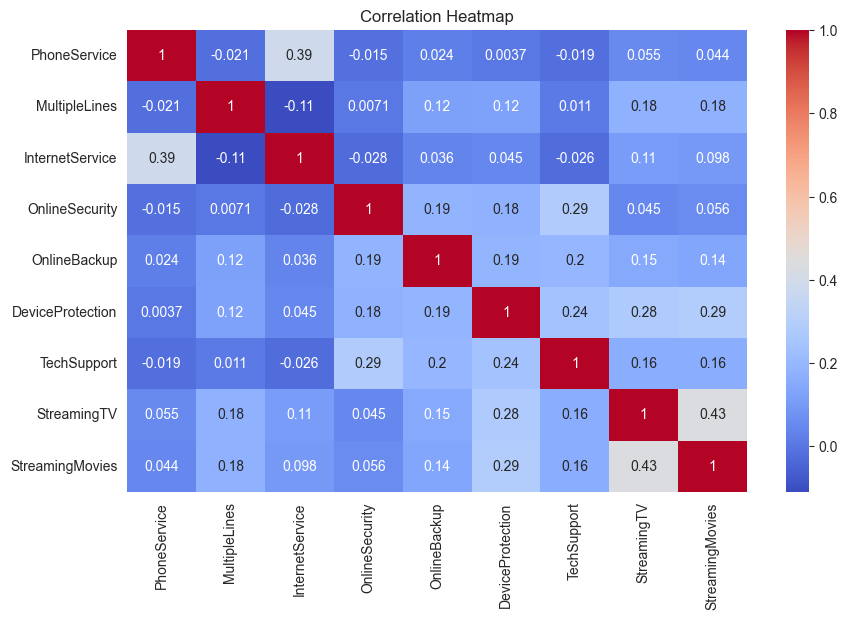

In [444]:
from sklearn.preprocessing import LabelEncoder

corr_df = df[corr_cols].copy()

le = LabelEncoder()

for col in corr_df.columns:
    corr_df[col] = le.fit_transform(corr_df[col])

plt.figure(figsize=(10,6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [445]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# split the data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
# Percentage of train and test data
train_percentage = (len(X_train) / len(X)) * 100
test_percentage = (len(X_test) / len(X)) * 100

print(f"Training Data Percentage: {train_percentage:.2f}%")
print(f"Testing Data Percentage: {test_percentage:.2f}%")

Train shape: (5634, 19) | Test shape: (1409, 19)
Training Data Percentage: 79.99%
Testing Data Percentage: 20.01%


In [450]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


Model: Logistic Regression
Accuracy: 81.7601
Precision: 0.6737
Recall: 0.6032
F1-Score: 0.6365

Confusion Matrix:
[[927 109]
 [148 225]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.89      0.88      1036
       Churn       0.67      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409


ROC-AUC Score: 0.8614


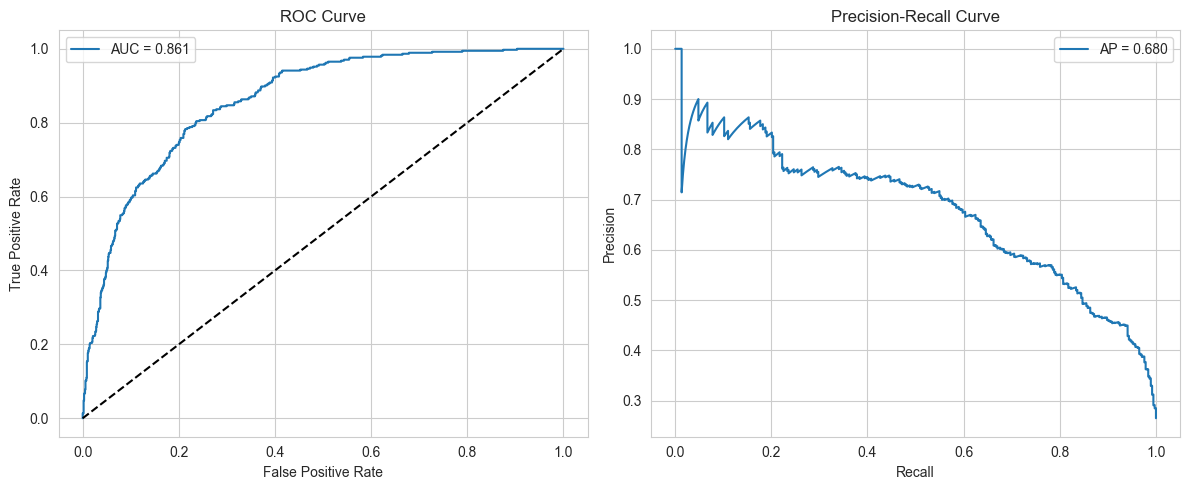

Average Precision Score: 0.6797


In [451]:
# Create Logistic Regression Model
Logistic_Regression = LogisticRegression(
    random_state=42,
    max_iter=2000
)

# Train Model
Logistic_Regression.fit(X_train_scaled, y_train)

# Predictions
y_pred = Logistic_Regression.predict(X_test_scaled)

# Basic Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Results
print("Model: Logistic Regression")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

# ===============================
# Extended Evaluation
# ===============================

# Probability predictions
y_prob = Logistic_Regression.predict_proba(X_test_scaled)[:, 1]

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Compute curves
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)

# Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

Model: Random Forest
Accuracy: 79.2761
Precision: 0.6494
Recall: 0.4718
F1-Score: 0.5466

Confusion Matrix:
[[941  95]
 [197 176]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1036
       Churn       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


ROC-AUC Score: 0.8390


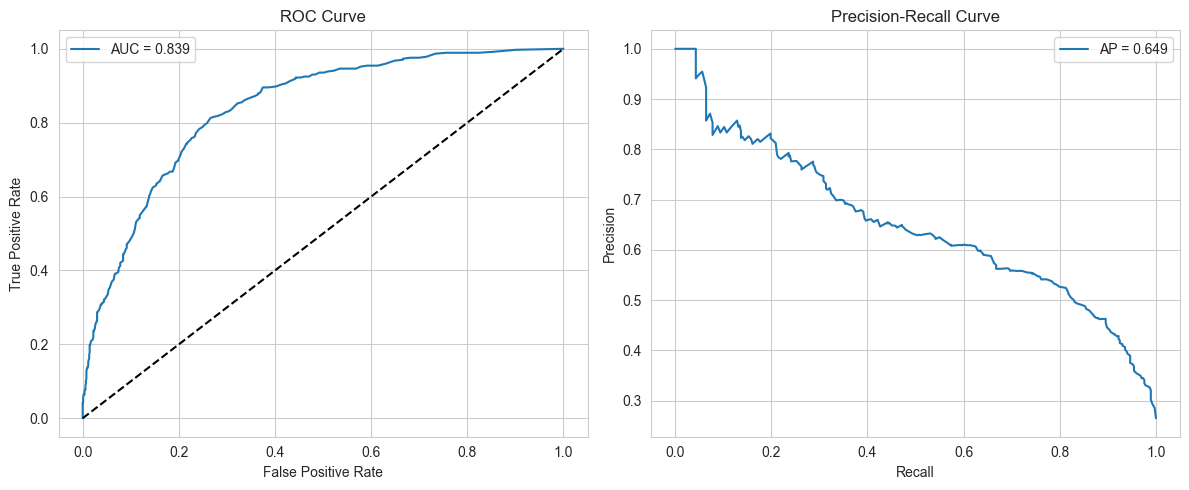

Average Precision Score: 0.6494


In [452]:
# Create Random Forest Model
Random_Forest= RandomForestClassifier(n_estimators=200, random_state=42)

# Train Model
Random_Forest.fit(X_train, y_train)

# Predictions
y_pred = Random_Forest.predict(X_test)


# Basic Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Results
print("Model: Random Forest")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

# ===============================
# Extended Evaluation
# ===============================

# Probability predictions
y_prob = Random_Forest.predict_proba(X_test)[:, 1]
y_pred = Random_Forest.predict(X_test)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Compute curves
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)

# Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

Model:  XGBoost
Accuracy: 79.2761
Precision: 0.6328
Recall: 0.5174
F1-Score: 0.5693

Confusion Matrix:
[[924 112]
 [180 193]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1036
       Churn       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409


ROC-AUC Score: 0.8381


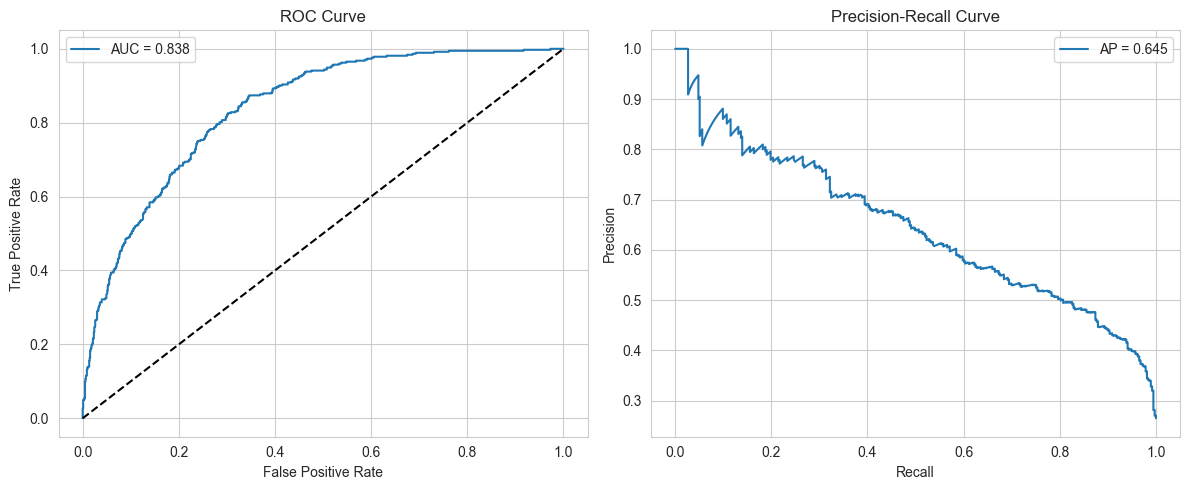

Average Precision Score: 0.6453


In [453]:
# Create XGBoost Model
XGBoost = XGBClassifier(eval_metric='logloss', random_state=42)

# Train Model
XGBoost.fit(X_train, y_train)

# Predictions
y_pred = XGBoost.predict(X_test)


# Basic Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Results
print("Model:  XGBoost")
print(f"Accuracy: {accuracy*100:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

# ===============================
# Extended Evaluation
# ===============================

# Probability predictions
y_prob =  XGBoost.predict_proba(X_test)[:, 1]
y_pred =  XGBoost.predict(X_test)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Compute curves
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)

# Plot Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average Precision Score: {ap_score:.4f}")

In [457]:
!pip install tensorflow

In [459]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [460]:
# Build ANN Model
ann_model = Sequential()

# Input layer + Hidden layer
ann_model.add(Dense(units=64, activation='relu', input_dim=X_train_scaled.shape[1]))

# Hidden layer
ann_model.add(Dense(units=32, activation='relu'))

# Dropout (avoid overfitting)
ann_model.add(Dropout(0.3))

# Output layer (binary classification)
ann_model.add(Dense(units=1, activation='sigmoid'))

In [461]:
# Compile Model
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [471]:
# Train Model
history = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8207 - loss: 0.3866 - val_accuracy: 0.8057 - val_loss: 0.4065
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8256 - loss: 0.3849 - val_accuracy: 0.8101 - val_loss: 0.4110
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8183 - loss: 0.3872 - val_accuracy: 0.7986 - val_loss: 0.4087
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8212 - loss: 0.3820 - val_accuracy: 0.8057 - val_loss: 0.4107
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8163 - loss: 0.3827 - val_accuracy: 0.8030 - val_loss: 0.4153
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8263 - loss: 0.3763 - val_accuracy: 0.8030 - val_loss: 0.4151
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8249 - loss: 0.3783 - val_accuracy: 0.8030 - val_loss: 0.4127
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8241 - loss: 0.3750 - val_accuracy: 0.

In [472]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [473]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [474]:
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

In [475]:
import os

print(os.getcwd())

C:\Users\Abhijit Dhara\OneDrive\Desktop\Project Material


In [476]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Abhijit_Dhara_Project_Abstracts.pdf', 'ABHIJIT_DHARA_TCCA_DA_DOCUMENTATION.docx', 'ABHIJIT_DHARA_TELECOM_CUSTOMER_CHURN_PREDICTION_USING_MACHINE_LEARNING.docx', 'app.py', 'columns.pkl', 'EDA.ipynb', 'eda_summary_plots.png', 'model.pkl', 'PG project front matter certificate.docx', 'requirements.txt', 'scaler.pkl', 'TCCAs.ipynb', 'TCCA_Documentation.docx', 'Telco Customer Churn Analysys.pdf', 'Telecom Customer Churn Prediction USING MACHINE LEARNING.pptx', 'Telecom(Telco) Customer Churn.csv', 'telecom-customer-churn-prediction.ipynb']


In [448]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.
